In [80]:
import pandas as pd
import matplotlib.pyplot as plt

import json
import os

In [81]:
schema_path = r"D:\Courses\Research\RL\CityLearnCode\CitylearnData\data\citylearn_challenge_2022_phase_all\schema.json"
with open(schema_path, 'r') as f:
    schema = json.load(f)
nominal_power = schema['buildings']['Building_2']['pv']['attributes']['nominal_power']

In [82]:
df_building2 = pd.read_csv(r"D:\Courses\Research\RL\CityLearnCode\CitylearnData\data\citylearn_challenge_2022_phase_all\Building_2.csv")
df_building2 = df_building2[["Equipment Electric Power [kWh]", "Solar Generation [W/kW]"]]
df_price = pd.read_csv(r"D:\Courses\Research\RL\CityLearnCode\CitylearnData\data\citylearn_challenge_2022_phase_all\pricing.csv")
df_price = df_price[["Electricity Pricing [$]"]]
merged_df = pd.concat([df_building2, df_price], axis=1)

In [83]:
merged_df["pv_power_kw"] = merged_df["Solar Generation [W/kW]"] * nominal_power/1000.0
merged_df["net_electricity_consumption_without_storage"] = merged_df["Equipment Electric Power [kWh]"] - merged_df['pv_power_kw']
merged_df["cost_non_shiftable_load_demand"] = merged_df["Equipment Electric Power [kWh]"] * merged_df["Electricity Pricing [$]"]
merged_df["cost_net_electricity_consumption_without_storage"] = merged_df['net_electricity_consumption_without_storage'] * merged_df["Electricity Pricing [$]"]

In [84]:
merged_df.head(10)

,Equipment Electric Power [kWh],Solar Generation [W/kW],Electricity Pricing [$],pv_power_kw,net_electricity_consumption_without_storage,cost_non_shiftable_load_demand,cost_net_electricity_consumption_without_storage
0,2.188750,0.000000,0.22,0.000000,2.188750,0.481525,0.481525
1,1.370667,0.000000,0.22,0.000000,1.370667,0.301547,0.301547
2,1.101250,0.000000,0.22,0.000000,1.101250,0.242275,0.242275
3,0.543217,0.000000,0.22,0.000000,0.543217,0.119508,0.119508
4,0.542833,0.000000,0.22,0.000000,0.542833,0.119423,0.119423
5,1.512433,0.000000,0.22,0.000000,1.512433,0.332735,0.332735
6,0.348683,5.608333,0.22,0.022433,0.326250,0.076710,0.071775
7,0.678617,29.500000,0.22,0.118000,0.560617,0.149296,0.123336
8,1.506500,96.754167,0.22,0.387017,1.119483,0.331430,0.246286
9,1.652117,225.454167,0.22,0.901817,0.750300,0.363466,0.165066


In [85]:
# ==== LOAD SIMULATION CSV ====
df_after_management = pd.read_csv(r"D:\Courses\Research\RL\CityLearnCode\RunCode\TD3\All_analysis\Rizwan_sir\1_Paper6\Eval_Task_145\timeseries.csv")
df_after_management.head(10)

,price_from_grid,action,battery_soc,non_shiftable_load_demand,pv_generation,battery_energy_consumption,net_consumption,pv_self_consumed,total_demand_for_self_sufficiency_rate,net_electricity_consumption_without_storage,costs,costs_baseline,emissions,emissions_baseline,reward
0,0.22,-0.198611,0.000000,2.188750,-0.000000,0.0,2.188750,0.000000,2.188750,2.188750,0.481525,0.481525,0.373673,0.373673,-0.904640
1,0.22,-0.033751,0.000000,1.370667,-0.000000,0.0,1.370667,0.000000,1.370667,1.370667,0.301547,0.301547,0.215632,0.215632,-0.726825
2,0.22,-0.035891,0.000000,1.101250,-0.000000,0.0,1.101250,0.000000,1.101250,1.101250,0.242275,0.242275,0.170146,0.170146,-0.358523
3,0.22,0.038158,0.000000,0.543217,-0.000000,0.0,0.543217,0.000000,0.543217,0.543217,0.119508,0.119508,0.081996,0.081996,-0.519451
4,0.22,-0.084171,3.476405,0.542833,-0.000000,0.0,0.787048,0.000000,0.787048,0.542833,0.173150,0.119423,0.119489,0.082413,-0.864425
5,0.22,0.042134,0.000000,1.512433,-0.000000,0.0,1.309735,0.000000,1.512433,1.512433,0.288142,0.332735,0.207054,0.239098,-0.393298
6,0.22,0.022337,3.838575,0.348683,-0.022433,0.0,0.595906,0.022433,0.618340,0.326250,0.131099,0.071775,0.096501,0.052833,-0.464360
7,0.22,-0.162626,5.873604,0.678617,-0.118000,0.0,0.703576,0.118000,0.821576,0.560617,0.154787,0.123336,0.115630,0.092135,-0.512828
8,0.22,-0.150640,0.000000,1.506500,-0.387017,0.0,0.777013,0.387017,1.506500,1.119483,0.170943,0.246286,0.148408,0.213819,-0.495198
9,0.22,-0.130454,0.000000,1.652117,-0.901817,0.0,0.750300,0.901817,1.652117,0.750300,0.165066,0.165066,0.152235,0.152235,-0.836605


## Unit_consumed

                Scenario  Energy [kWh]
0   Without PV & Battery   9350.290338
1          PV Generation   5423.290034
2           With PV only   6554.324959
3      With PV & Battery   5251.746186
4  PV Loss After Battery    920.123014


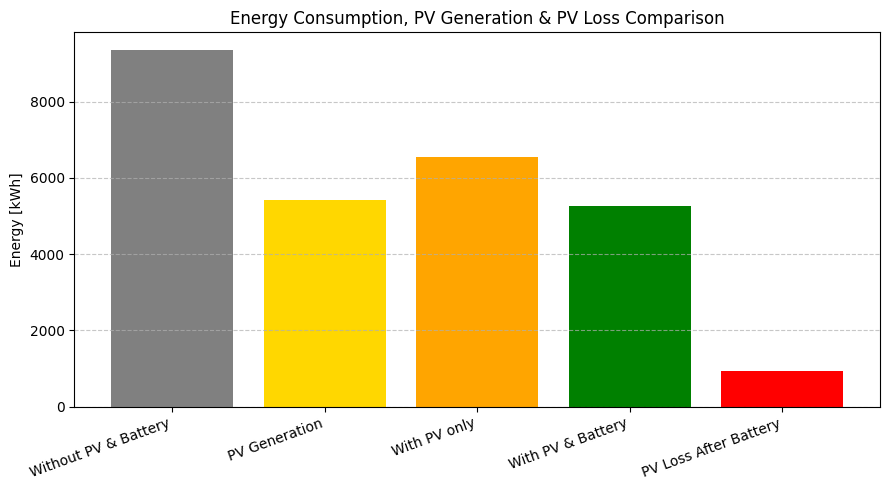

In [86]:
import pandas as pd
import matplotlib.pyplot as plt

# Calculations from df_after_management
unit_consumed__without_PV_and_Battery = df_after_management["non_shiftable_load_demand"].sum()
unit_consumed_When_PV_installed = df_after_management["net_electricity_consumption_without_storage"].clip(lower=0).sum()
unit_consumed_When_both_PV_and_Battery_installed = df_after_management["net_consumption"].clip(lower=0).sum()
pv_loss_after_battery = (-df_after_management["net_consumption"].clip(upper=0)).sum()
total_pv_generation = df_after_management["pv_generation"].abs().sum()  # ensure positive

# Create summary table
df_summary = pd.DataFrame({
    "Scenario": [
        "Without PV & Battery",
        "PV Generation",
        "With PV only",
        "With PV & Battery",
        "PV Loss After Battery"
    ],
    "Energy [kWh]": [
        unit_consumed__without_PV_and_Battery,
        total_pv_generation,
        unit_consumed_When_PV_installed,
        unit_consumed_When_both_PV_and_Battery_installed,
        pv_loss_after_battery
    ]
})

# Print table
print(df_summary)

# Plot
colors = ["gray", "gold", "orange", "green", "red"]
plt.figure(figsize=(9, 5))
plt.bar(df_summary["Scenario"], df_summary["Energy [kWh]"], color=colors)
plt.ylabel("Energy [kWh]")
plt.title("Energy Consumption, PV Generation & PV Loss Comparison")
plt.xticks(rotation=20, ha="right")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## Cost

Home/Residential Solar Storage
EnergySage data shows residential solar batteries average about $1,300 per kWh before federal tax incentives, and around $1,000 per kWh after the 30% tax credit

Calendar life: ~10–15 years (depending on climate, usage, and manufacturer warranty)

Cycle life: ~3,000–6,000 cycles at 80% depth of discharge (DoD)

One cycle = full charge and discharge

Daily cycling → ~8–16 years before capacity drops to ~70–80% of original

                Scenario     Cost [$]
0   Without PV & Battery  2753.525290
1           With PV only  1965.396604
2      With PV & Battery  1304.244586
3       Saving (PV only)   788.128686
4  Saving (PV + Battery)  1449.280704
5  Saving due to Battery   661.152018


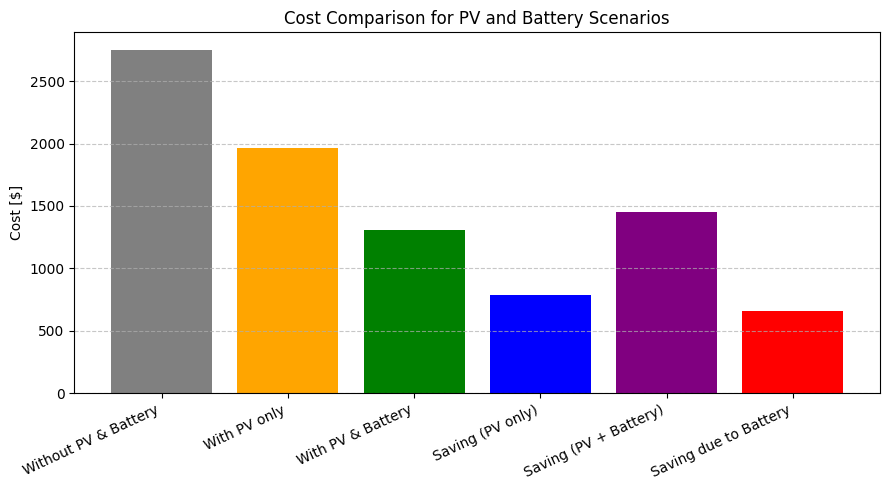

In [87]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Cost calculations ---
Cost__without_PV_and_Battery = merged_df["cost_non_shiftable_load_demand"].clip(lower=0).sum()
Cost_When_PV_installed = df_after_management["costs_baseline"].clip(lower=0).sum()
Cost_When_both_PV_and_Battery_installed = df_after_management["costs"].clip(lower=0).sum()

# --- Savings calculations ---
saving_PV_only = Cost__without_PV_and_Battery - Cost_When_PV_installed
saving_PV_Battery = Cost__without_PV_and_Battery - Cost_When_both_PV_and_Battery_installed
saving_due_to_battery = Cost_When_PV_installed - Cost_When_both_PV_and_Battery_installed

# --- Summary table ---
df_cost_summary = pd.DataFrame({
    "Scenario": [
        "Without PV & Battery",
        "With PV only",
        "With PV & Battery",
        "Saving (PV only)",
        "Saving (PV + Battery)",
        "Saving due to Battery"
    ],
    "Cost [$]": [
        Cost__without_PV_and_Battery,
        Cost_When_PV_installed,
        Cost_When_both_PV_and_Battery_installed,
        saving_PV_only,
        saving_PV_Battery,
        saving_due_to_battery
    ]
})

# Print the table
print(df_cost_summary)

# --- Plot ---
plt.figure(figsize=(9, 5))
colors = ["gray", "orange", "green", "blue", "purple", "red"]
plt.bar(df_cost_summary["Scenario"], df_cost_summary["Cost [$]"], color=colors)
plt.ylabel("Cost [$]")
plt.title("Cost Comparison for PV and Battery Scenarios")
plt.xticks(rotation=25, ha="right")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# Performance evaluation matrix

### 1 Cost, Net Electricity Consumption and Co2 Emission 

                              Metric     Ratio
0                         Cost Ratio  0.663604
1  Net Electricity Consumption Ratio  0.801264
2                 CO₂ Emission Ratio  0.786933


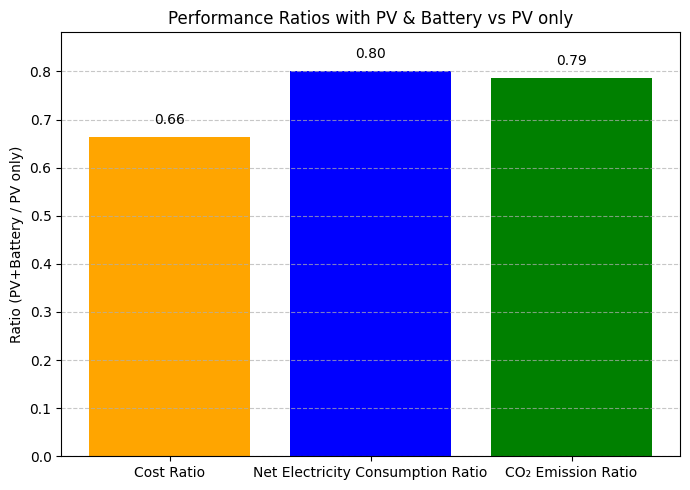

In [88]:

# --- Calculations ---
cost_ratio = Cost_When_both_PV_and_Battery_installed / Cost_When_PV_installed
net_elec_ratio = unit_consumed_When_both_PV_and_Battery_installed / unit_consumed_When_PV_installed
emission_ratio = df_after_management["emissions"].clip(lower=0).sum() / df_after_management["emissions_baseline"].clip(lower=0).sum()

# --- Create DataFrame ---
df_ratios = pd.DataFrame({
    "Metric": ["Cost Ratio", "Net Electricity Consumption Ratio", "CO₂ Emission Ratio"],
    "Ratio": [cost_ratio, net_elec_ratio, emission_ratio]
})

# Print table
print(df_ratios)

# --- Bar plot ---
plt.figure(figsize=(7, 5))
bars = plt.bar(df_ratios["Metric"], df_ratios["Ratio"], color=["orange", "blue", "green"])
plt.ylabel("Ratio (PV+Battery / PV only)")
plt.title("Performance Ratios with PV & Battery vs PV only")
plt.ylim(0, max(df_ratios["Ratio"]) * 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Annotate bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.02, f"{height:.2f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()


### 2 Load Factor 

#### 2.1 Annual Load Factor

              Scenario  Annual Load Factor
0  Before PV & Battery            0.844021
1              Only PV            0.923340
2         PV + Battery            0.920680


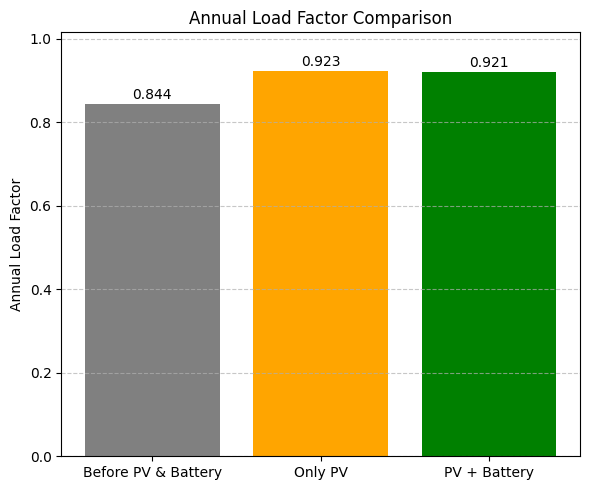

In [89]:
from citylearn.cost_function import CostFunction as cf
import pandas as pd
import matplotlib.pyplot as plt

# --- Calculations ---
alf_before = cf.load_factor(df_after_management["non_shiftable_load_demand"].values.tolist(), 8760)
alf_pv_only = cf.load_factor(df_after_management["net_electricity_consumption_without_storage"].values.tolist(), 8760)
alf_pv_batt = cf.load_factor(df_after_management["net_consumption"].values.tolist(), 8760)

# If they are lists, take the first element
if isinstance(alf_before, (list, tuple)):
    alf_before = alf_before[0]
    alf_pv_only = alf_pv_only[0]
    alf_pv_batt = alf_pv_batt[0]

# --- Create DataFrame ---
df_alf = pd.DataFrame({
    "Scenario": ["Before PV & Battery", "Only PV", "PV + Battery"],
    "Annual Load Factor": [alf_before, alf_pv_only, alf_pv_batt]
})

# Display table
print(df_alf)

# --- Bar Plot ---
plt.figure(figsize=(6, 5))
bars = plt.bar(df_alf["Scenario"], df_alf["Annual Load Factor"], color=["gray", "orange", "green"])
plt.ylabel("Annual Load Factor")
plt.title("Annual Load Factor Comparison")
plt.ylim(0, max(df_alf["Annual Load Factor"]) * 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Annotate bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.005, f"{height:.3f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()


2.2 Monthly Load Factor

   Month  Before PV & Battery   Only PV  PV + Battery
0    Aug             0.690702  0.864964      0.851181
1    Sep             0.796505  0.918501      0.909091
2    Oct             0.767827  0.889703      0.872457
3    Nov             0.810303  0.911685      0.895460
4    Dec             0.786401  0.804427      0.809660
5    Jan             0.765750  0.828178      0.798655
6    Feb             0.760458  0.855341      0.845062
7    Mar             0.814914  0.964996      0.962235
8    Apr             0.839187  1.031283      1.016541
9    May             0.820861  1.006102      0.991680
10   Jun             0.721008  0.915008      0.905078
11   Jul             0.660097  0.850151      0.839677


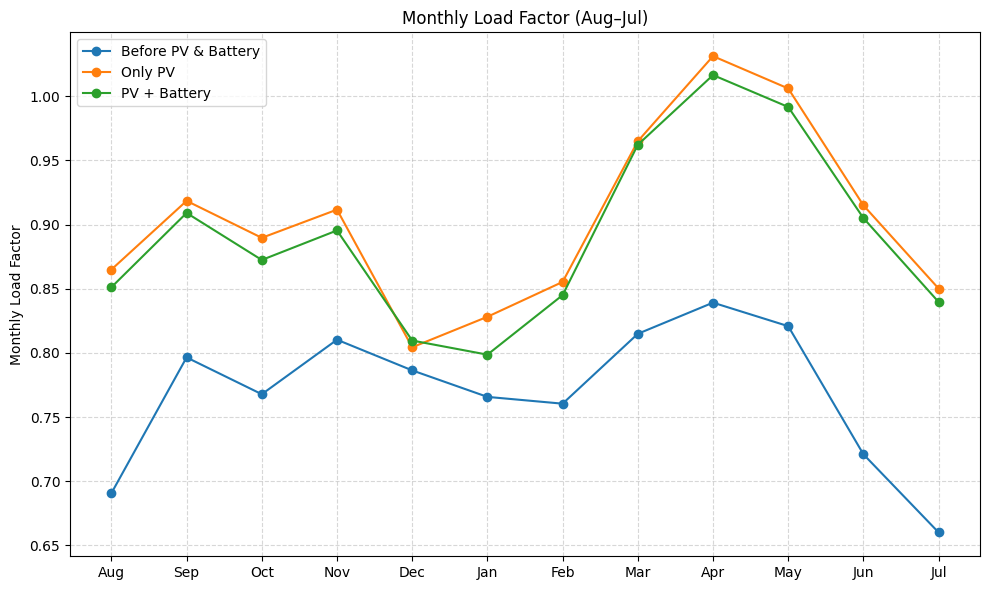

In [90]:
# Month labels from August to July
months = ["Aug", "Sep", "Oct", "Nov", "Dec", "Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul"]

# Function to calculate monthly load factor
def monthly_load_factors(series):
    values = series.values.tolist()
    results = []
    start_idx = 0
    days_in_month = [31, 30, 31, 30, 31, 31, 28, 31, 30, 31, 30, 31]  # Aug to Jul
    
    for days in days_in_month:
        hours = days * 24
        month_vals = values[start_idx:start_idx + hours]
        lf = cf.load_factor(month_vals, hours)
        
        # If it's a list or tuple, take the first element
        if isinstance(lf, (list, tuple)):
            lf = lf[0]
        
        results.append(lf)
        start_idx += hours
    
    return results

# Calculate monthly load factors
before_pv_battery = monthly_load_factors(df_after_management["non_shiftable_load_demand"])
only_pv = monthly_load_factors(df_after_management["net_electricity_consumption_without_storage"])
pv_battery = monthly_load_factors(df_after_management["net_consumption"])

# Create DataFrame
df_monthly_lf = pd.DataFrame({
    "Month": months,
    "Before PV & Battery": before_pv_battery,
    "Only PV": only_pv,
    "PV + Battery": pv_battery
})

print(df_monthly_lf)

# Optional: Plot
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.plot(months, before_pv_battery, marker='o', label="Before PV & Battery")
plt.plot(months, only_pv, marker='o', label="Only PV")
plt.plot(months, pv_battery, marker='o', label="PV + Battery")
plt.ylabel("Monthly Load Factor")
plt.title("Monthly Load Factor (Aug–Jul)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


In [91]:
import pandas as pd
from citylearn.cost_function import CostFunction

cf = CostFunction()

# Month labels (Aug to Jul)
months = ["Aug", "Sep", "Oct", "Nov", "Dec", "Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul"]

# Function to calculate monthly load factor
def monthly_load_factors(series):
    values = series.values.tolist()
    results = []
    start_idx = 0
    for days in [31,30,31,30,31,31,28,31,30,31,30,31]:  # Aug-Jul days
        hours = days * 24
        month_vals = values[start_idx:start_idx + hours]
        lf = cf.load_factor(month_vals, hours)

        # If cf.load_factor returns list/tuple, take the first element
        if isinstance(lf, (list, tuple, pd.Series)):
            lf = lf[0]
        
        results.append(float(lf))
        start_idx += hours
    return results

# Calculate monthly load factors
before_pv_battery = monthly_load_factors(df_after_management["non_shiftable_load_demand"])
only_pv = monthly_load_factors(df_after_management["net_electricity_consumption_without_storage"])
pv_battery = monthly_load_factors(df_after_management["net_consumption"])

# Create DataFrame
df_monthly_lf = pd.DataFrame({
    "Month": months,
    "Before PV & Battery": before_pv_battery,
    "Only PV": only_pv,
    "PV + Battery": pv_battery
})

# Highlight the max value in each column
def highlight_max(s):
    is_max = s == s.max()
    return ['background-color: #4CAF50; color: white; font-weight: bold' if v else '' for v in is_max]

# Style the table
styled_df = (
    df_monthly_lf.style
    .format({"Before PV & Battery": "{:.3f}", "Only PV": "{:.3f}", "PV + Battery": "{:.3f}"})
    .apply(highlight_max, subset=["Before PV & Battery", "Only PV", "PV + Battery"])
    .set_caption("📊 Monthly Load Factor (Aug–Jul)")
    .set_table_styles([
        {'selector': 'caption', 'props': [('color', '#333'), ('font-size', '16px'), ('font-weight', 'bold')]},
        {'selector': 'th', 'props': [('background-color', '#004c6d'), ('color', 'white'), ('padding', '8px')]},
        {'selector': 'td', 'props': [('padding', '6px')]}
    ])
    .background_gradient(cmap="YlGnBu", axis=1)
)

styled_df


,Month,Before PV & Battery,Only PV,PV + Battery
0,Aug,0.691,0.865,0.851
1,Sep,0.797,0.919,0.909
2,Oct,0.768,0.890,0.872
3,Nov,0.810,0.912,0.895
4,Dec,0.786,0.804,0.810
5,Jan,0.766,0.828,0.799
6,Feb,0.760,0.855,0.845
7,Mar,0.815,0.965,0.962
8,Apr,0.839,1.031,1.017
9,May,0.821,1.006,0.992


### 3 Comparitive analysis



## SOTA

In [92]:
df_after_management_proposed = pd.read_csv(r"D:\Courses\Research\RL\CityLearnCode\RunCode\TD3\All_analysis\Rizwan_sir\1_Paper6\Eval_Task_145\timeseries.csv")
df_after_management_SB3_TD3 = pd.read_csv(r"D:\Courses\Research\RL\CityLearnCode\RunCode\TD3\All_analysis\Rizwan_sir\1_Paper6\8_basline3\timeseries.csv")
marlin_SAC = pd.read_csv(r"D:\Courses\Research\RL\CityLearnCode\RunCode\TD3\All_analysis\Rizwan_sir\1_Paper6\5_MERLIN\timeseries.csv")

df_after_management_1_paper24_MSC = pd.read_csv(r"D:\Courses\Research\RL\CityLearnCode\RunCode\TD3\All_analysis\Rizwan_sir\1_Paper6\5_RBC 2_PAPER24 1_paper24_MSC Building2\timeseries.csv")
df_after_management_2_paper24_TOU = pd.read_csv(r"D:\Courses\Research\RL\CityLearnCode\RunCode\TD3\All_analysis\Rizwan_sir\1_Paper6\5_RBC      2_PAPER2 42_paper24_TOU Building2\timeseries.csv")
df_after_management_3_SelfConsumptionFontanaRBC = pd.read_csv(r"D:\Courses\Research\RL\CityLearnCode\RunCode\TD3\All_analysis\Rizwan_sir\1_Paper6\5_RBC 3_SelfConsumptionFontanaRBC\timeseries.csv")
df_after_management_4_TOUPeakReductionFontanaRBC = pd.read_csv(r"D:\Courses\Research\RL\CityLearnCode\RunCode\TD3\All_analysis\Rizwan_sir\1_Paper6\5_RBC 4_TOUPeakReductionFontanaRBC\timeseries.csv")
df_after_management_5_TOURateOptimizationFontanaRBC = pd.read_csv(r"D:\Courses\Research\RL\CityLearnCode\RunCode\TD3\All_analysis\Rizwan_sir\1_Paper6\5_RBC 5_TOURateOptimizationFontanaRBC\timeseries.csv")

df_after_management_6_TD3 = pd.read_csv(r"D:\Courses\Research\RL\CityLearnCode\RunCode\TD3\All_analysis\Rizwan_sir\1_Paper6\0_SOTA 3_paper6 3_TD3_Paper_Reward\timeseries.csv")
df_after_management_6_DDPG = pd.read_csv(r"D:\Courses\Research\RL\CityLearnCode\RunCode\TD3\All_analysis\Rizwan_sir\1_Paper6\0_SOTA 3_paper6 4_DDPG\timeseries.csv")
# df_after_management_6_TD3_our_reward = pd.read_csv(r"D:\CityLearn\0_SOTA\3_paper6\2_TD3_our_Reward\timeseries.csv") 
# df_after_management_6_DDPG_our_reward = pd.read_csv(r"D:\CityLearn\0_SOTA\3_paper6\1_DDPG_On our Reward\timeseries.csv")

df_after_management_26_DDPG = pd.read_csv(r"D:\Courses\Research\RL\CityLearnCode\RunCode\TD3\All_analysis\Rizwan_sir\1_Paper6\0_SOTA 4_Paper26 3_DDPG\timeseries.csv")
#df_after_management_26_DDPG_our_reward = pd.read_csv(r"D:\CityLearn\0_SOTA\4_Paper26\1_DDPG_our_reward\timeseries.csv")
df_after_management_26_TD3 = pd.read_csv(r"D:\Courses\Research\RL\CityLearnCode\RunCode\TD3\All_analysis\Rizwan_sir\1_Paper6\0_SOTA 4_Paper26 4_TD3\timeseries.csv")
# df_after_management_26_TD3_our_reward = pd.read_csv(r"D:\CityLearn\0_SOTA\4_Paper26\2_TD3_our_reward\timeseries.csv")

In [93]:
models = {
    "Proposed": df_after_management_proposed,
    "SB3_TD3": df_after_management_SB3_TD3,
    "MARLIN": marlin_SAC,

    "MSC_paper_24": df_after_management_1_paper24_MSC,
    "TOU_paper24": df_after_management_2_paper24_TOU,
    "SelfConsumption_merlin": df_after_management_3_SelfConsumptionFontanaRBC,
    "TOU_PeakReduction_MARLIN": df_after_management_4_TOUPeakReductionFontanaRBC,
    "TOU_RateOpt_MARLIN": df_after_management_5_TOURateOptimizationFontanaRBC,
    
    "TD3_paper6": df_after_management_6_TD3,
    "DDPG_paper6": df_after_management_6_DDPG,
    #"TD3_ourReward_paper6": df_after_management_6_TD3_our_reward,
    #"DDPG_ourReward_paper6": df_after_management_6_DDPG_our_reward,
    
    "DDPG_paper26": df_after_management_26_DDPG,
   # "DDPG_ourReward_paper26": df_after_management_26_DDPG_our_reward,
    #"TD3_ourReward_paper26": df_after_management_26_TD3_our_reward, 
    "TD3_paper26": df_after_management_26_TD3, 
}

# Unit 

In [94]:
import pandas as pd
import matplotlib.pyplot as plt

def create_energy_summary(models_data):
    """
    models_data: dict
        Keys = model names (str)
        Values = dataframe for that model (pd.DataFrame)
    """
    summary = {}

    for model_name, df in models_data.items():
        unit_consumed__without_PV_and_Battery = df["non_shiftable_load_demand"].sum()
        unit_consumed_When_PV_installed = df["net_electricity_consumption_without_storage"].clip(lower=0).sum()
        unit_consumed_When_both_PV_and_Battery_installed = df["net_consumption"].clip(lower=0).sum()
        # pv_loss_after_battery = df["net_consumption"].clip(lower=0).sum()
        # total_pv_generation = df["pv_generation"].abs().sum()

        summary[model_name] = [
            unit_consumed__without_PV_and_Battery,
            unit_consumed_When_PV_installed,
            unit_consumed_When_both_PV_and_Battery_installed,
         #   pv_loss_after_battery,
         #   total_pv_generation
        ]

    # Create DataFrame
    df_summary = pd.DataFrame.from_dict(
        summary, orient="index",
        columns=[
            "unit_consumed__without_PV_and_Battery",
            "Net_electricity_consumption_without_storage (Baseline)",
            "Net_electricity_consumption"
        #    "With PV & Battery",
          #  "PV Loss After Battery"
        ]
    )

    # Numbered models instead of long names
    df_summary.index = range(1, len(df_summary) + 1)

    # Plot
    ax = df_summary.plot(kind="bar", figsize=(12,6), width=0.8)
    ax.set_ylabel("Energy [kWh]")
    ax.set_xlabel("Model Index")
    ax.set_title("Energy Comparison Across Models")
    plt.xticks(rotation=0)

    # Move legend outside
    ax.legend(title="Scenario", bbox_to_anchor=(1.05, 1), loc="upper left")

    # Add a text box mapping model numbers to names
    mapping_text = "\n".join(
        f"{i+1}: {name}" for i, name in enumerate(models_data.keys())
    )
    plt.gcf().text(
        1.15, 0.5, mapping_text, fontsize=9,
        va="center", ha="left", bbox=dict(facecolor="white", edgecolor="black")
    )

    plt.tight_layout()
    plt.show()

    return df_summary


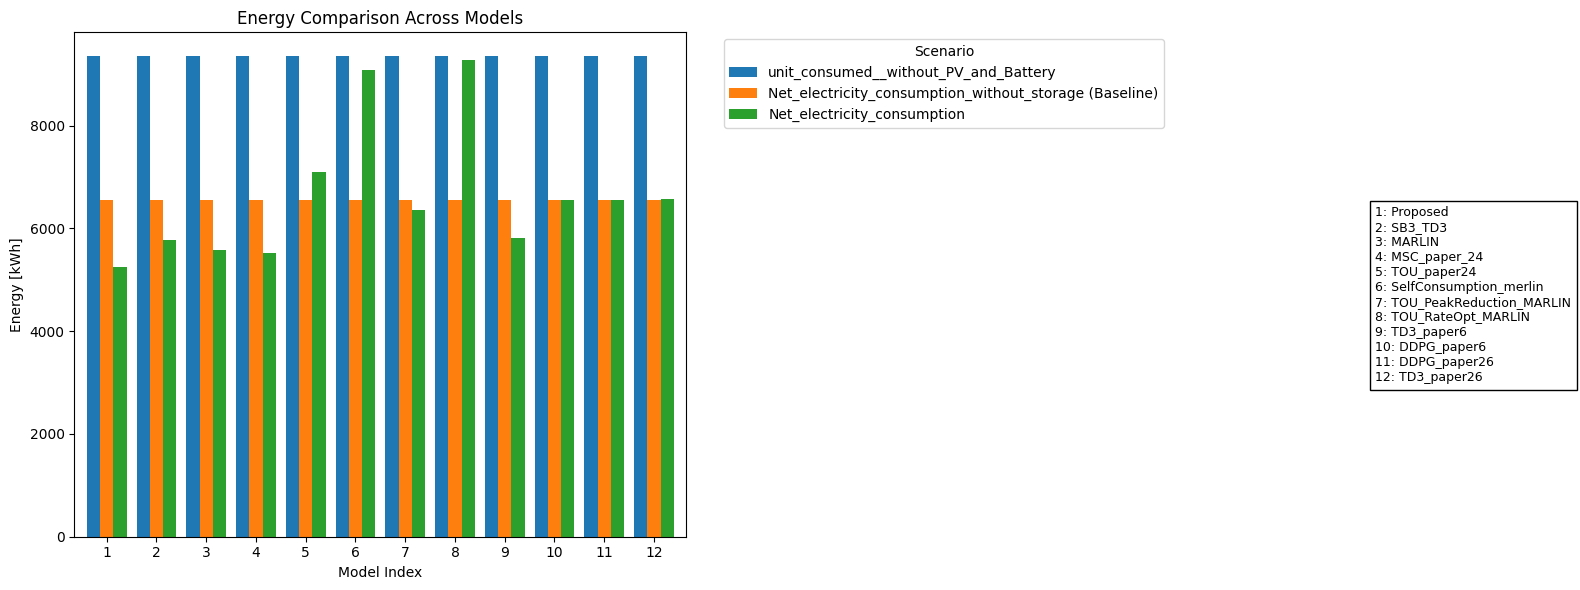

,unit_consumed__without_PV_and_Battery,Net_electricity_consumption_without_storage (Baseline),Net_electricity_consumption
Proposed,"9,350","6,554","5,252"
SB3_TD3,"9,350","6,554","5,785"
MARLIN,"9,350","6,554","5,590"
MSC_paper_24,"9,350","6,554","5,520"
TOU_paper24,"9,350","6,554","7,103"
SelfConsumption_merlin,"9,350","6,554","9,082"
TOU_PeakReduction_MARLIN,"9,350","6,554","6,368"
TOU_RateOpt_MARLIN,"9,350","6,554","9,270"
TD3_paper6,"9,350","6,554","5,813"
DDPG_paper6,"9,350","6,554","6,561"


In [95]:
# Suppose you already ran:
df_summary = create_energy_summary(models)

# Now style it:
def style_summary_table(df_summary, models):
    df_styled = df_summary.copy()
    df_styled.index = list(models.keys())  # replace 1,2,3 with model names

    return (
        df_styled.style
        .format("{:,.0f}")  # show integers without decimals
        .set_table_styles(
            [{"selector": "th",
              "props": [("background-color", "#22921E"),
                        ("font-weight", "bold")]}]
        )
        .set_caption("Energy Summary for Each Model")
        .set_properties(**{"text-align": "center"})
    )

# Call it
style_summary_table(df_summary, models)


# Cost

In [96]:
import pandas as pd
import matplotlib.pyplot as plt

def create_cost_summary(models_data):
    """
    models_data: dict
        Keys = model names (str)
        Values = dataframe for that model (pd.DataFrame)
    Each DataFrame must contain columns:
        - 'non_shiftable_load_demand'
        - 'net_electricity_consumption_without_storage'
        - 'net_consumption'
        - 'electricity_pricing'
    """
    summary = {}

    for model_name, df in models_data.items():
        # Cost without PV & Battery
        Cost__without_PV_and_Battery = (df["non_shiftable_load_demand"] * df["price_from_grid"]).sum()

        # Cost with PV only
        Cost_When_PV_installed = df["costs_baseline"].clip(lower=0).sum()

        # Cost with PV + Battery
        Cost_When_both_PV_and_Battery_installed = df["costs"].clip(lower=0).sum()

        # Savings
        saving_pv_only = Cost__without_PV_and_Battery - Cost_When_PV_installed
        saving_pv_batt = Cost__without_PV_and_Battery - Cost_When_both_PV_and_Battery_installed
        saving_due_to_batt = Cost_When_PV_installed - Cost_When_both_PV_and_Battery_installed

        summary[model_name] = [
            Cost__without_PV_and_Battery,
            Cost_When_PV_installed,
            Cost_When_both_PV_and_Battery_installed,
            saving_pv_only,
            saving_pv_batt,
            saving_due_to_batt
        ]

    # Create DataFrame
    df_summary = pd.DataFrame.from_dict(
        summary, orient="index",
        columns=[
            "Cost Without PV & Battery",
            "Cost With PV only",
            "Cost With PV & Battery",
            "Saving (PV only)",
            "Saving (PV + Battery)",
            "Saving due to Battery"
        ]
    )

    # Numbered models instead of long names
    df_summary.index = range(1, len(df_summary) + 1)

    # ----- Plot 1: Costs -----
    ax1 = df_summary[["Cost Without PV & Battery", "Cost With PV only", "Cost With PV & Battery"]].plot(
        kind="bar", figsize=(12,6), width=0.8
    )
    ax1.set_ylabel("Cost [$]")
    ax1.set_xlabel("Model Index")
    ax1.set_title("Cost Comparison Across Models")
    plt.xticks(rotation=0)

    ax1.legend(title="Scenario", bbox_to_anchor=(1.05, 1), loc="upper left")

    # Add a text box mapping model numbers to names
    mapping_text = "\n".join(
        f"{i+1}: {name}" for i, name in enumerate(models_data.keys())
    )
    plt.gcf().text(
        1.15, 0.5, mapping_text, fontsize=9,
        va="center", ha="left", bbox=dict(facecolor="white", edgecolor="black")
    )

    plt.tight_layout()
    plt.show()

    # ----- Plot 2: Savings -----
    ax2 = df_summary[["Saving (PV only)", "Saving (PV + Battery)", "Saving due to Battery"]].plot(
        kind="bar", figsize=(12,6), width=0.8
    )
    ax2.set_ylabel("Savings [$]")
    ax2.set_xlabel("Model Index")
    ax2.set_title("Savings Comparison Across Models")
    plt.xticks(rotation=0)

    ax2.legend(title="Savings Type", bbox_to_anchor=(1.05, 1), loc="upper left")

    # Reuse the model mapping box
    plt.gcf().text(
        1.15, 0.5, mapping_text, fontsize=9,
        va="center", ha="left", bbox=dict(facecolor="white", edgecolor="black")
    )

    plt.tight_layout()
    plt.show()

    return df_summary


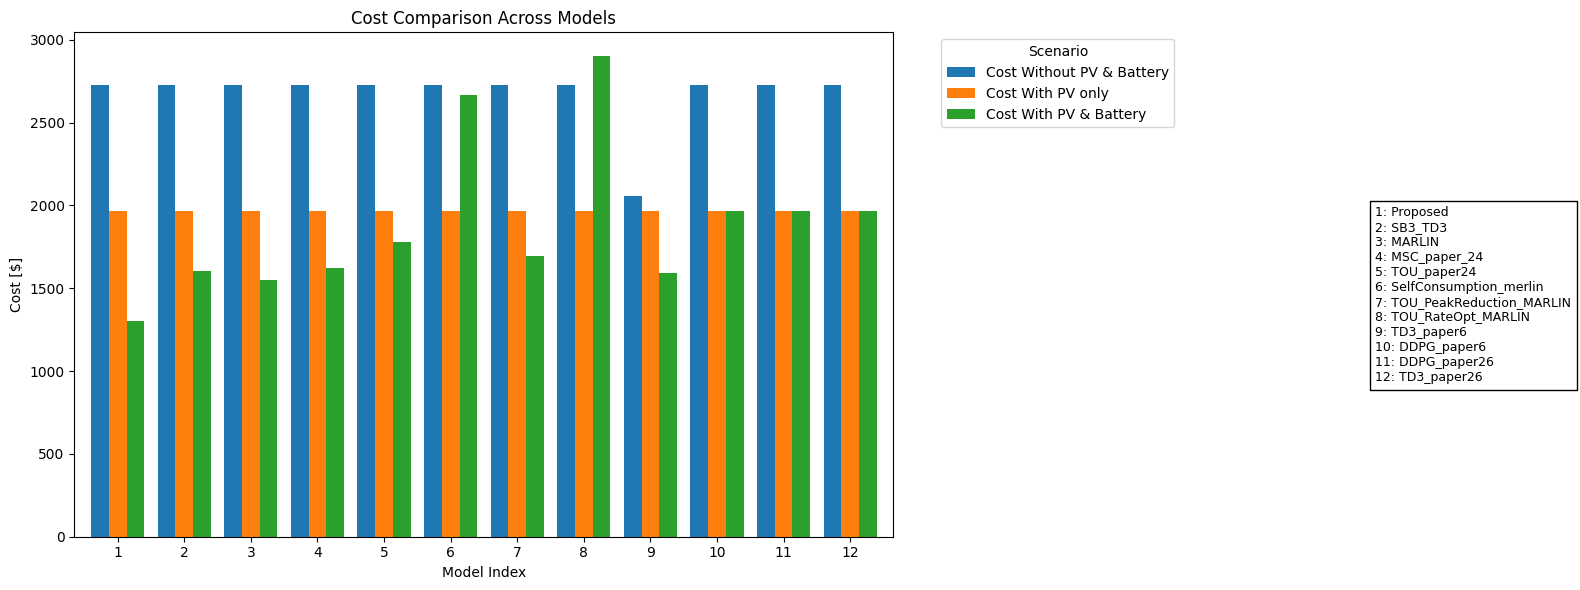

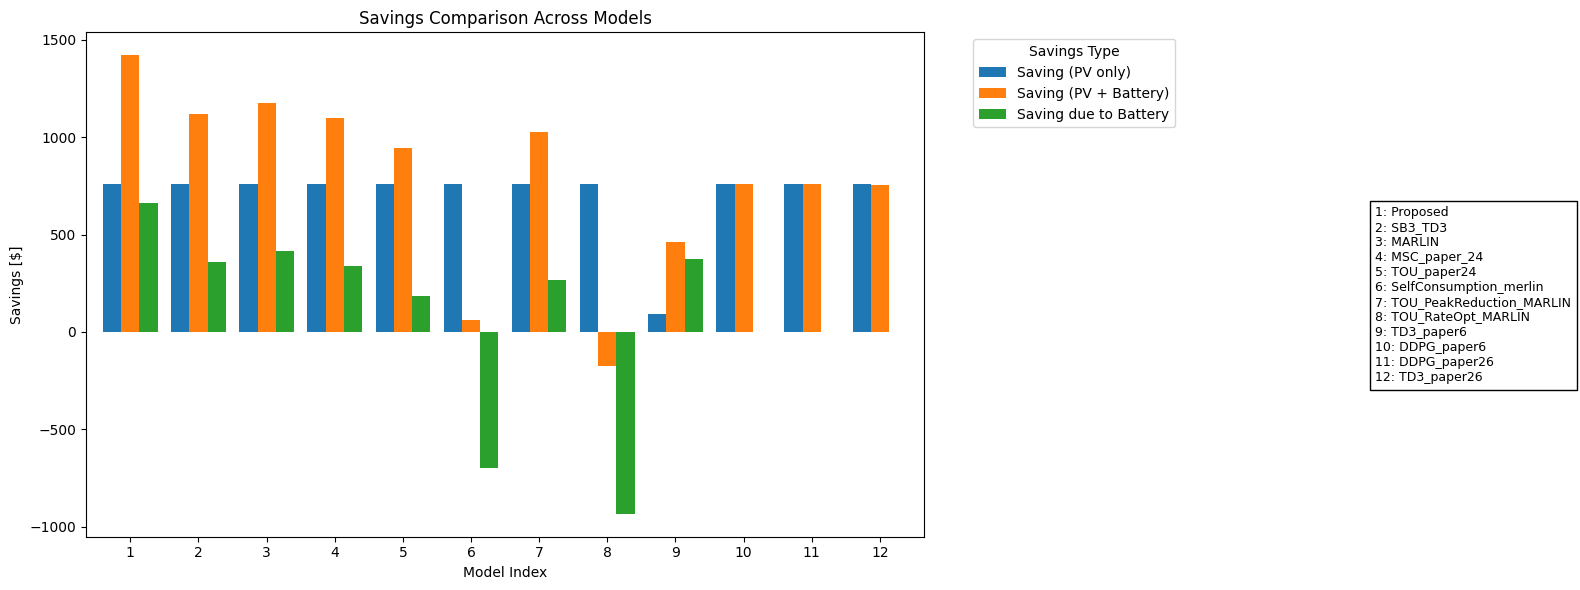

,Cost Without PV & Battery,Cost With PV only,Cost With PV & Battery,Saving (PV only),Saving (PV + Battery),Saving due to Battery
1,2724.540414,1965.396604,1304.244586,759.143810,1420.295828,661.152018
2,2724.540401,1965.396593,1604.839101,759.143809,1119.701300,360.557491
3,2724.540414,1965.396604,1547.759635,759.143810,1176.780779,417.636969
4,2724.540414,1965.396604,1624.670424,759.143810,1099.869990,340.726180
5,2724.540414,1965.396604,1779.861878,759.143810,944.678535,185.534726
6,2724.540414,1965.396604,2664.591222,759.143810,59.949191,-699.194618
7,2724.540414,1965.396604,1696.863322,759.143810,1027.677092,268.533282
8,2724.540414,1965.396604,2899.294009,759.143810,-174.753596,-933.897405
9,2057.063874,1965.396593,1593.538609,91.667281,463.525265,371.857984
10,2724.540401,1965.396597,1966.942036,759.143804,757.598366,-1.545439


In [97]:

create_cost_summary(models)


# Cost, Net Electricity Consumption and Co2 Emission, SSR, SCR

In [98]:
import pandas as pd
import matplotlib.pyplot as plt

def create_performance_ratios(models_data):
    """
    Calculate and display cost, net electricity, emission ratios, 
    PV self-consumption rate, and self-sufficiency rate 
    for multiple models with PV & Battery vs PV only.
    
    Parameters:
    -----------
    models_data : dict
        Keys = model names (str)
        Values = DataFrames for each model.
    """
    results = []
    model_map = {}  # To store number -> model name mapping

    for idx, (model_name, df) in enumerate(models_data.items(), start=1):
        try:
            # --- Energy and cost calculations ---
            Cost__without_PV_and_Battery = (df["non_shiftable_load_demand"] * df["price_from_grid"]).sum()
            Cost_When_PV_installed = df["costs_baseline"].clip(lower=0).sum()
            Cost_When_both_PV_and_Battery_installed = df["costs"].clip(lower=0).sum()
            
            unit_consumed_When_PV_installed = df["net_electricity_consumption_without_storage"].clip(lower=0).sum()
            unit_consumed_When_both_PV_and_Battery_installed = df["net_consumption"].clip(lower=0).sum()
            
            # --- Ratios ---
            cost_ratio = Cost_When_both_PV_and_Battery_installed / Cost_When_PV_installed
            net_elec_ratio = unit_consumed_When_both_PV_and_Battery_installed / unit_consumed_When_PV_installed
            emission_ratio = df["emissions"].clip(lower=0).sum() / df["emissions_baseline"].clip(lower=0).sum()
            
            # --- PV self-consumption & self-sufficiency ---
            pv_generation = -df["pv_generation"].sum()
            pv_self_consumed = df["pv_self_consumed"].clip(lower=0).sum()
            Demand__without_PV_and_Battery = (df["non_shiftable_load_demand"]).sum()

            if pv_generation > 0:
                pv_self_consumption_rate = pv_self_consumed / pv_generation
            else:
                pv_self_consumption_rate = 0

            self_sufficiency_rate = pv_self_consumed / Demand__without_PV_and_Battery

            results.append({
                "Model": idx,  # Use numbers instead of names
                "Cost Ratio": cost_ratio,
                "Net Electricity Consumption Ratio": net_elec_ratio,
                "CO₂ Emission Ratio": emission_ratio,
                "PV Self-Consumption Rate": pv_self_consumption_rate,
                "Self-Sufficiency Rate": self_sufficiency_rate
            })
            
            # Save mapping
            model_map[idx] = model_name

        except Exception as e:
            print(f"Skipping {model_name} due to error: {e}")

    # --- Create DataFrame ---
    df_ratios_all = pd.DataFrame(results).set_index("Model")
    
    # --- Print clean table ---
    styled_table = df_ratios_all.style.format("{:.2f}") \
        .background_gradient(cmap="Oranges", subset=["Cost Ratio"]) \
        .background_gradient(cmap="Blues", subset=["Net Electricity Consumption Ratio"]) \
        .background_gradient(cmap="Greens", subset=["CO₂ Emission Ratio"]) \
        .background_gradient(cmap="Purples", subset=["PV Self-Consumption Rate"]) \
        .background_gradient(cmap="Reds", subset=["Self-Sufficiency Rate"]) \
        .set_table_styles([{'selector': 'th', 'props': [('background-color', "#1e7453"), ('font-weight', 'bold')]}])
    
    display(styled_table)

    # --- Plot grouped bar chart ---
    ax = df_ratios_all.plot(kind="bar", figsize=(14, 6), rot=0, colormap="Set2")
    plt.ylabel("Value / Ratio")
    plt.title("Performance Metrics Across Models")
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.tight_layout()

    # --- Add model mapping box ---
    mapping_text = "\n".join([f"{k} → {v}" for k, v in model_map.items()])
    plt.gcf().text(1.02, 0.5, mapping_text, fontsize=10, va="center")

    plt.show()

    return df_ratios_all, model_map


,Cost Ratio,Net Electricity Consumption Ratio,CO₂ Emission Ratio,PV Self-Consumption Rate,Self-Sufficiency Rate
Model,,,,,
1,0.66,0.80,0.79,0.90,0.52
2,0.82,0.88,0.87,0.76,0.44
3,0.79,0.85,0.86,0.82,0.47
4,0.83,0.84,0.85,0.81,0.47
5,0.91,1.08,1.03,0.52,0.30
6,1.36,1.39,1.38,0.92,0.53
7,0.86,0.97,0.96,0.84,0.49
8,1.48,1.41,1.43,0.59,0.34
9,0.81,0.89,0.88,0.75,0.44


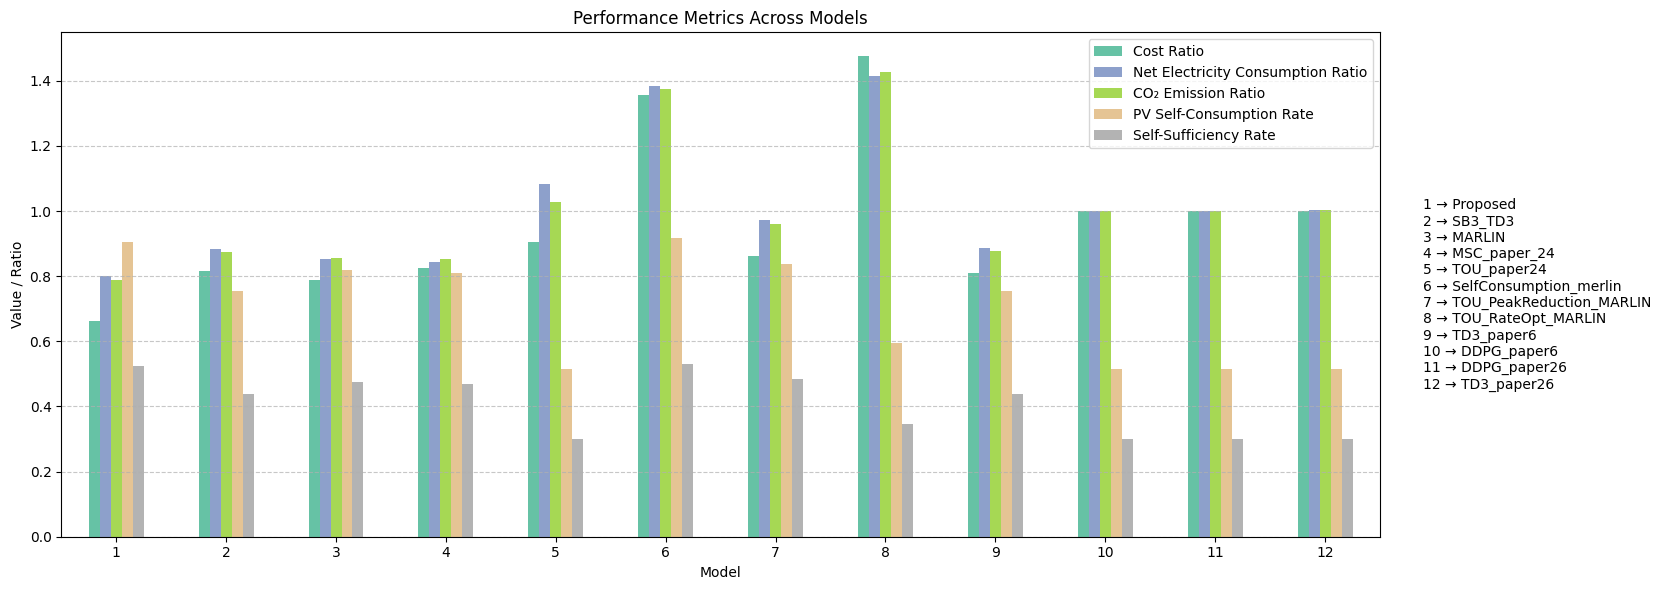

(       Cost Ratio  Net Electricity Consumption Ratio  CO₂ Emission Ratio  \
 Model                                                                      
 1        0.663604                           0.801264            0.786933   
 2        0.816547                           0.882590            0.874993   
 3        0.787505                           0.852893            0.856754   
 4        0.826637                           0.842142            0.851544   
 5        0.905599                           1.083743            1.027873   
 6        1.355752                           1.385659            1.375807   
 7        0.863369                           0.971559            0.960873   
 8        1.475170                           1.414278            1.427668   
 9        0.810797                           0.886958            0.878900   
 10       1.000786                           1.001072            1.001152   
 11       1.000769                           1.000873            1.000930   

In [99]:

create_performance_ratios(models)


# Annual load factor (ALF)

In [100]:
from citylearn.cost_function import CostFunction as cf
import pandas as pd
import matplotlib.pyplot as plt

def create_annual_load_factor(models_data):
    """
    Calculate annual load factor (ALF) for multiple models.
    
    Parameters:
    -----------
    models_data : dict
        Keys = model names (str)
        Values = DataFrames for each model.
        Each DataFrame must have columns:
            - 'non_shiftable_load_demand'
            - 'net_electricity_consumption_without_storage'
            - 'net_consumption'
    
    Returns:
    --------
    df_alf_all : pd.DataFrame
        Annual load factor for each model and scenario
    """
    summary = {}

    for model_name, df in models_data.items():
        # Calculate ALF for each scenario
        alf_before = cf.load_factor(df["non_shiftable_load_demand"].values.tolist(), 8760)
        alf_pv_only = cf.load_factor(df["net_electricity_consumption_without_storage"].values.tolist(), 8760)
        alf_pv_batt = cf.load_factor(df["net_consumption"].values.tolist(), 8760)

        # If returned as list, take the first element
        if isinstance(alf_before, (list, tuple)):
            alf_before = alf_before[0]
            alf_pv_only = alf_pv_only[0]
            alf_pv_batt = alf_pv_batt[0]

        summary[model_name] = [alf_before, alf_pv_only, alf_pv_batt]

    # Create DataFrame
    df_alf_all = pd.DataFrame.from_dict(
        summary, orient="index",
        columns=["Before PV & Battery", "Only PV", "PV + Battery"]
    )

    # Numbered models for plotting
    df_alf_all.index = range(1, len(df_alf_all) + 1)

    # --- Plot ---
    ax = df_alf_all.plot(kind="bar", figsize=(12,6), width=0.8)
    ax.set_ylabel("Annual Load Factor")
    ax.set_xlabel("Model Index")
    ax.set_title("Annual Load Factor Comparison Across Models")
    plt.xticks(rotation=0)

    # Legend outside
    ax.legend(title="Scenario", bbox_to_anchor=(1.05, 1), loc="upper left")

    # Add model mapping box
    mapping_text = "\n".join(f"{i+1}: {name}" for i, name in enumerate(models_data.keys()))
    plt.gcf().text(1.15, 0.5, mapping_text, fontsize=9,
                   va="center", ha="left", bbox=dict(facecolor="white", edgecolor="black"))

    plt.tight_layout()
    plt.show()

    return df_alf_all


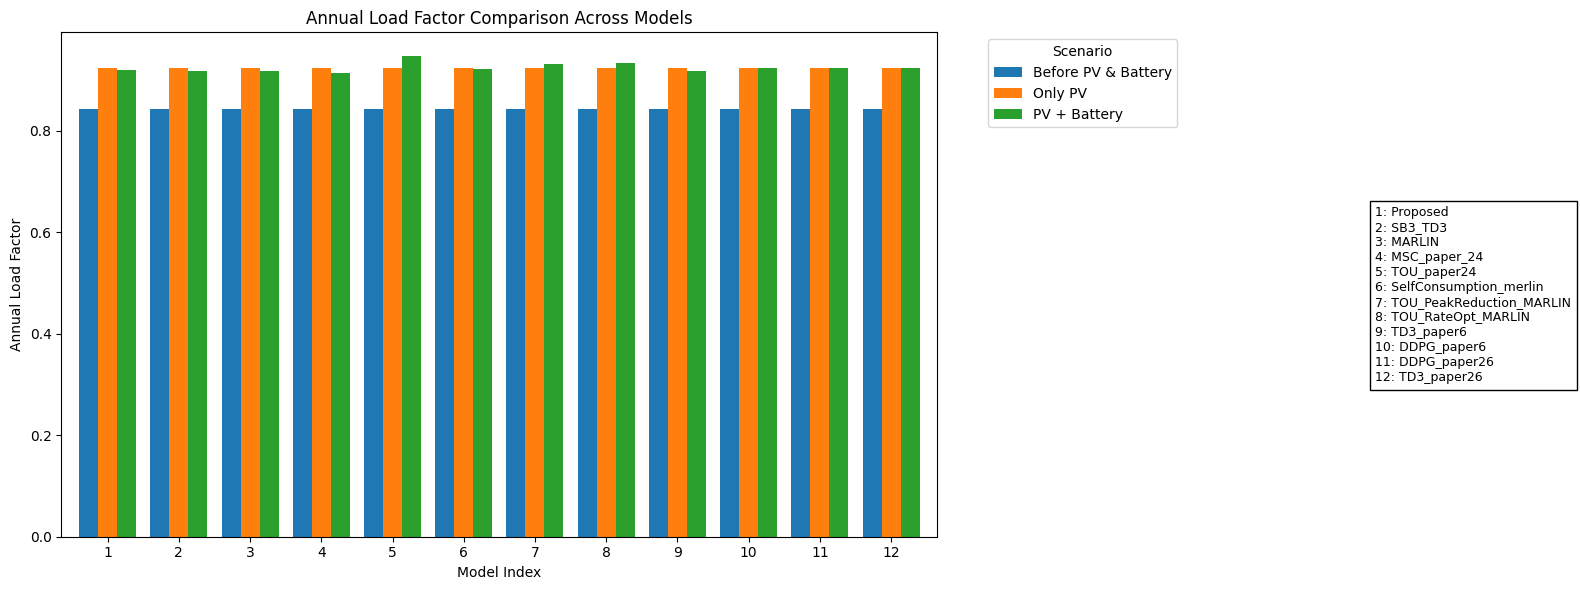

    Before PV & Battery   Only PV  PV + Battery
1              0.844021  0.923340      0.920680
2              0.844021  0.923340      0.918235
3              0.844021  0.923340      0.918536
4              0.844003  0.923331      0.914509
5              0.844003  0.923331      0.946862
6              0.844003  0.923331      0.922081
7              0.844003  0.923331      0.931403
8              0.844003  0.923331      0.934087
9              0.844021  0.923340      0.917086
10             0.844021  0.923340      0.923203
11             0.844021  0.923340      0.923203
12             0.844021  0.923340      0.923247


In [101]:
df_alf_all = create_annual_load_factor(models)
print(df_alf_all)


#### V1

In [102]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_accumulated_cost(models_data):
    """
    Plot accumulated cost over time for multiple models.
    Legend now adds numbering to model names.
    """
    accumulated_costs = {}
    for model_name, df in models_data.items():
        accumulated_costs[model_name] = df["costs"].cumsum()

    df_accumulated_cost = pd.DataFrame(accumulated_costs)

    # Professional colors
    colors = plt.cm.tab10.colors

    fig, ax = plt.subplots(figsize=(10, 6))

    for i, model_name in enumerate(df_accumulated_cost.columns):
        ax.plot(df_accumulated_cost.index,
                df_accumulated_cost[model_name],
                label=f"{i+1}. {model_name}",   # ← ADDED NUMBERING HERE
                color=colors[i % len(colors)],
                linewidth=2.0)

    # Clean axes: only left and bottom spines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.0)
    ax.spines["bottom"].set_linewidth(1.0)
    ax.spines["left"].set_color("black")
    ax.spines["bottom"].set_color("black")

    ax.set_xlabel("Time step", fontsize=12)
    ax.set_ylabel("Accumulated Cost [\$]", fontsize=12)

    # Legend INSIDE the plot, on the LEFT side (upper left corner)
    ax.legend(loc="upper left", 
              bbox_to_anchor=(0.01, 0.99),
              borderaxespad=0,
              frameon=True,
              fancybox=False,
              edgecolor="black",
              fontsize=10.5)

    plt.tight_layout()
    plt.show()

    return df_accumulated_cost


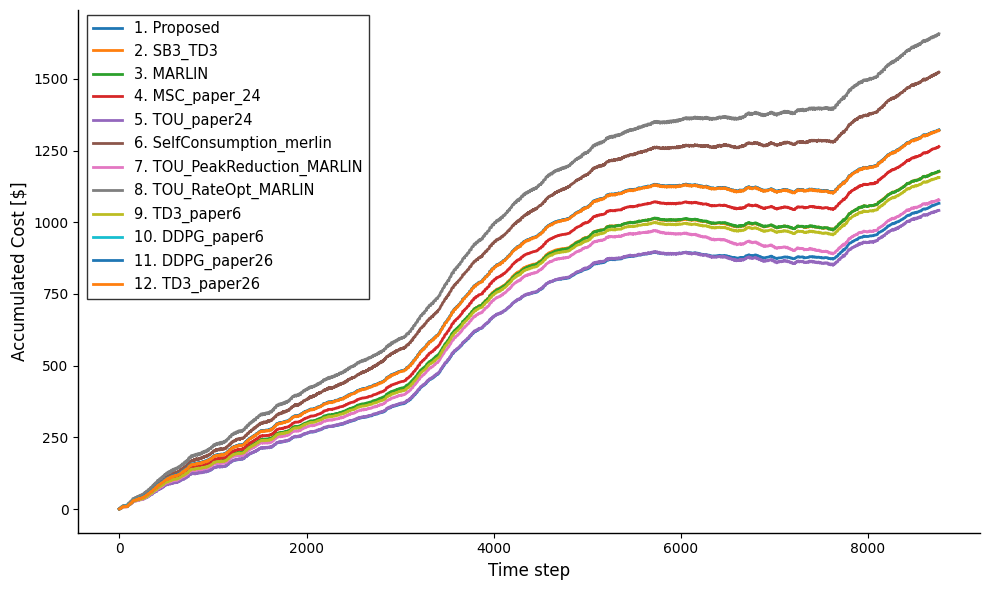

In [103]:
df_acc_cost = plot_accumulated_cost(models)
# print(df_acc_cost.head())


#### V3

In [104]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_accumulated_cost(models_data):
    """
    Strict Roman numeral order:
    I = Proposed model
    II, III, IV... = all other models in order
    """

    # Compute cumulative cost
    accumulated = {name: df["costs"].cumsum() for name, df in models_data.items()}
    df = pd.DataFrame(accumulated)

    fig, ax = plt.subplots(figsize=(10, 6))

    # Roman numeral converter
    def to_roman(n):
        vals = [1000,900,500,400,100,90,50,40,10,9,5,4,1]
        syms = ["M","CM","D","CD","C","XC","L","XL","X","IX","V","IV","I"]
        roman = ""
        i = 0
        while n > 0:
            for _ in range(n // vals[i]):
                roman += syms[i]
                n -= vals[i]
            i += 1
        return roman

    handles = []
    labels = []

    # 1. First identify proposed model
    proposed = None
    for col in df.columns:
        if "proposed" in col.lower():
            proposed = col
            break

    # 2. Plot proposed model first
    if proposed is not None:
        h = ax.plot(df.index, df[proposed], linewidth=2.5)[0]
        handles.append(h)
        labels.append("I")               # Always I = proposed

    # 3. Now plot all other models in order using a simple counter
    counter = 2
    for col in df.columns:
        if col == proposed:
            continue

        h = ax.plot(df.index, df[col], linewidth=2.0)[0]
        handles.append(h)
        labels.append(to_roman(counter))
        counter += 1
    ax.set_xlabel("Time step", fontsize=12)
    ax.set_ylabel("Accumulated Cost [$]", fontsize=12)
    
    # Legend
    ax.legend(handles, labels, ncol=6,
              loc="lower left",
              bbox_to_anchor=(0, 1.02, 1, 0.2))

    plt.show()


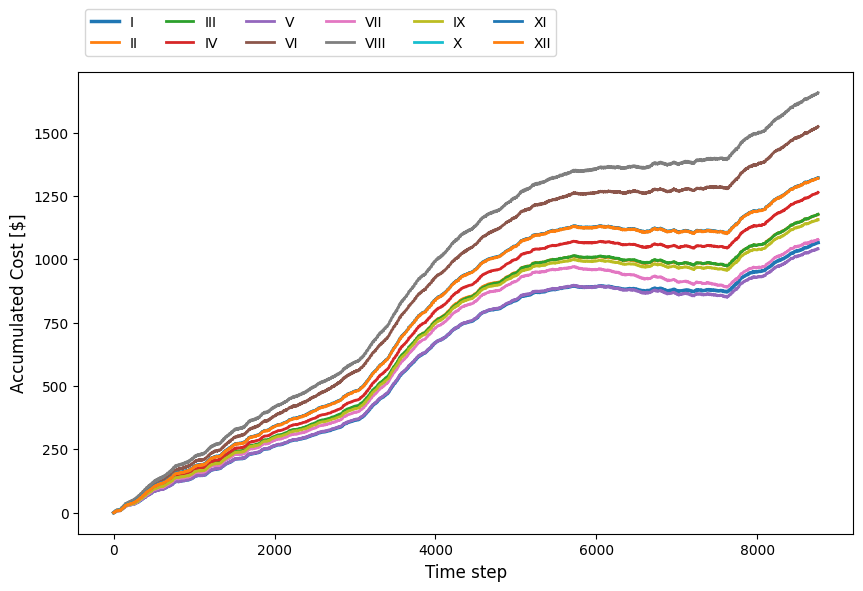

In [105]:
df_acc_cost = plot_accumulated_cost(models)


## Rizwan sb Request

In [106]:
models = {
    "Proposed": df_after_management_proposed,

}

In [77]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_hourly_means_all_models(models, start="2016-08-01", periods=8760, freq="H"):
    """
    Plot hourly mean profiles for common variables + net consumption of each model.
    Clean, publication-ready style: only left & bottom axes, no top/right spines.
    """
    results = {}

    for model_name, df in models.items():
        df = df.copy()
        if not isinstance(df.index, pd.DatetimeIndex):
            df.index = pd.date_range(start=start, periods=len(df), freq=freq)
        df["Hour"] = df.index.hour
        results[model_name] = df

    # Common variables (same across all models)
    ref_df = next(iter(results.values()))
    hourly_common = ref_df.groupby("Hour")[[
        "non_shiftable_load_demand",
        "pv_generation",
        "net_electricity_consumption_without_storage"
    ]].mean()

    # Create figure and axis
    fig, ax = plt.subplots(figsize=(12, 7))

    # --- Plot common profiles ---
    ax.plot(hourly_common.index, hourly_common["non_shiftable_load_demand"],
            color="black", linewidth=2.5, label="Non-shiftable Load")
    ax.plot(hourly_common.index, hourly_common["pv_generation"],
            color="#ff7f0e", linewidth=2.5, label="PV Generation")
    ax.plot(hourly_common.index, hourly_common["net_electricity_consumption_without_storage"],
            color="#1f77b4", linewidth=2, linestyle="--", label="Net cons. w/o storage")

    # --- Plot net consumption for each model ---
    for model_name, df in results.items():
        hourly_data = df.groupby("Hour")["net_consumption"].mean()

        if "proposed" in model_name.lower():
            ax.plot(hourly_data.index, hourly_data.values,
                    color="#2ca02c", linewidth=3.2, linestyle="-",
                    label="Proposed - Net Consumption")
        else:
            ax.plot(hourly_data.index, hourly_data.values,
                    color="#9467bd", linewidth=1.4, linestyle="--", alpha=0.85,
                    label=f"{model_name} - Net Consumption")

    # --- Clean axes: remove top and right spines ---
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.0)
    ax.spines["bottom"].set_linewidth(1.0)

    # Axis labels and ticks
    ax.set_xlabel("Hour of Day", fontsize=12)
    ax.set_ylabel("Mean Energy [kWh]", fontsize=12)
    ax.set_xticks(range(0, 24, 2))

    # Legend inside lower-left corner
    ax.legend(loc="lower left",
              bbox_to_anchor=(0.05, 0.05),
              borderaxespad=0,
              frameon=True,
              fancybox=False,
              edgecolor="black",
              fontsize=10.5)

    plt.tight_layout()
    plt.show()

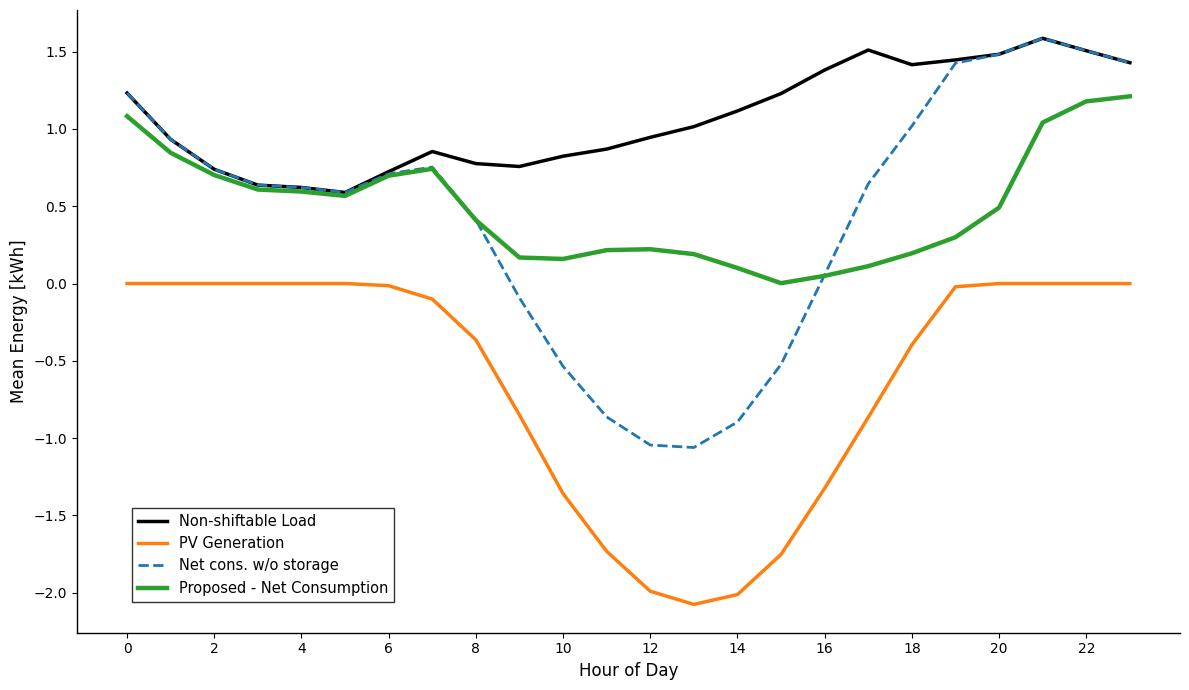

In [78]:
plot_hourly_means_all_models(models)


None


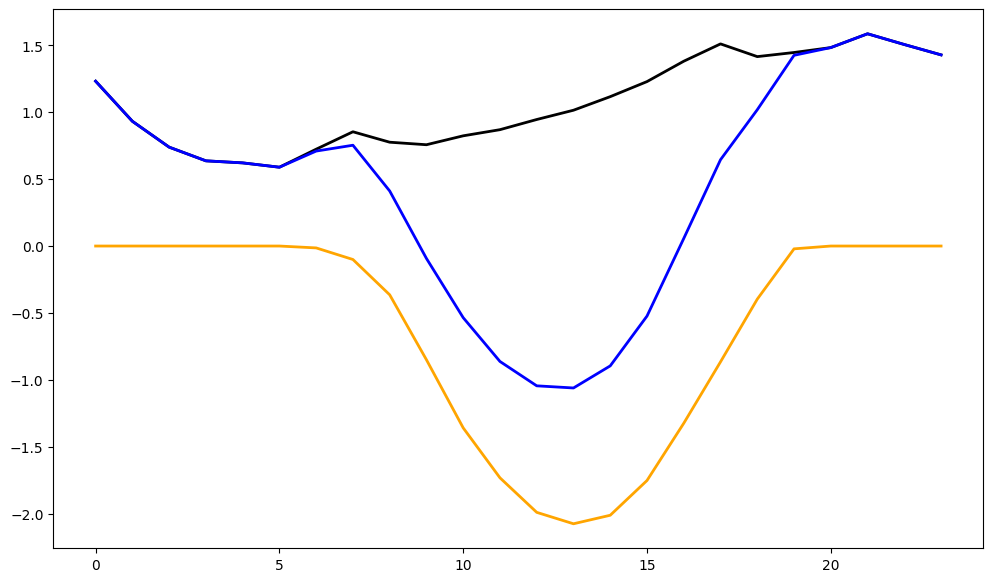

In [79]:
def plot_hourly_means_all_models(models, start="2016-08-01", periods=8760, freq="H"):
    """
    Plot hourly mean profiles for common variables + net consumption of each model.
    Assumes 1 year of hourly data (8760 hours).
    """
    results = {}

    for model_name, df in models.items():
        df = df.copy()

        # Ensure DateTimeIndex
        if not isinstance(df.index, pd.DatetimeIndex):
            df.index = pd.date_range(start=start, periods=len(df), freq=freq)

        # Add Hour column
        df["Hour"] = df.index.hour
        results[model_name] = df

    # Take first model for common variables
    first_model_df = next(iter(results.values()))
    variables_common = [
        "non_shiftable_load_demand",
        "pv_generation",
        "net_electricity_consumption_without_storage"
    ]
    hourly_common = first_model_df.groupby("Hour")[variables_common].mean().reset_index()

    plt.figure(figsize=(12, 7))

    # --- Plot common variables ---
    plt.plot(hourly_common["Hour"], hourly_common["non_shiftable_load_demand"], 
             color="black", linewidth=2, label="Non-shiftable Load")
    plt.plot(hourly_common["Hour"], hourly_common["pv_generation"], 
             color="orange", linewidth=2, label="PV Generation")
    plt.plot(hourly_common["Hour"], hourly_common["net_electricity_consumption_without_storage"], 
             color="blue", linewidth=2, label="Net cons. w/o storage")

print(plot_hourly_means_all_models(models))

# Action SOC Consumption, Cridit Yahya 

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter, DayLocator, WeekdayLocator
import datetime as dt
import os

# =======================
# CONFIG
# =======================
mode = "automate"   # "manual" or "automate"
base_path = r"D:\CityLearn\51_Paper\1_paper6\1_task25_TD3\One Episode Data Collection"
plots_to_generate = ["first_week", 'last_week']   # give list of [first_week, last_week, month, year]
building_id = 2
# =======================
def plot_graph(file_path, start_date, end_date, save_name, building_name, plot_type="week"):
    """Generate and save plot for given date range"""
    df = pd.read_csv(file_path)

    # ✅ Handle datetime column creation
    if "datetime" in df.columns:
        df["datetime"] = pd.to_datetime(df["datetime"])
    elif "date" in df.columns:
        df["datetime"] = pd.to_datetime(df["date"])
    elif "timestep" in df.columns:
        start_datetime = pd.to_datetime("2016-01-01 00:00:00")
        df["datetime"] = start_datetime + pd.to_timedelta(df["timestep"], unit="h")
    else:
        start_datetime = pd.to_datetime("2016-01-01 00:00:00")
        df["datetime"] = start_datetime + pd.to_timedelta(range(len(df)), unit="h")

    df = df.sort_values("datetime").reset_index(drop=True)

    # Slice
    mask = (df["datetime"] >= start_date) & (df["datetime"] <= end_date)
    period_data = df.loc[mask]

    if period_data.empty:
        print(f"⚠️ No data for {building_name} between {start_date} and {end_date}")
        return

    # Create subplots
    fig, axs = plt.subplots(3, 1, sharex=True, figsize=(12, 10), gridspec_kw={'hspace': 0.3})
    for ax in axs:
        ax.set_facecolor('#f0f0f0')

    # Top plot: Net Consumption
    axs[0].plot(period_data['datetime'], period_data['net_consumption'], linewidth=2, color='green', label='TD3')
    axs[0].plot(period_data['datetime'], period_data['net_electricity_consumption_without_storage'], linewidth=2, color='black', linestyle='--', label='baseline')
    axs[0].set_ylabel('Net Electricity Consumption\n(kWh)')
    axs[0].legend(loc='upper center', ncol=2, frameon=False)

    # Dynamic Y
    ymin = min(period_data['net_consumption'].min(), period_data['net_electricity_consumption_without_storage'].min())
    ymax = max(period_data['net_consumption'].max(), period_data['net_electricity_consumption_without_storage'].max())
    yrange = ymax - ymin if ymax > ymin else 1
    axs[0].set_ylim(ymin - 0.2*yrange, ymax + 0.2*yrange)

    # SOC
    axs[1].plot(period_data['datetime'], period_data['battery_soc'], linewidth=2, color='red')
    axs[1].set_ylabel('SOC')

    # Action
    axs[2].plot(period_data['datetime'], period_data['action'], linewidth=2, color='blue')
    axs[2].set_ylabel('Action')

    # Format x-axis
    if plot_type == "week":
        axs[2].xaxis.set_major_locator(DayLocator(interval=1))
        axs[2].xaxis.set_major_formatter(DateFormatter('%m/%d/%Y'))
    elif plot_type == "month":
        axs[2].xaxis.set_major_locator(WeekdayLocator(interval=1))
        axs[2].xaxis.set_major_formatter(DateFormatter('%m/%d/%Y'))
    elif plot_type == "year":
        axs[2].xaxis.set_major_formatter(DateFormatter('%b %Y'))

    # ✅ Tight x limits
    for ax in axs:
        ax.set_xlim(period_data['datetime'].iloc[0], period_data['datetime'].iloc[-1])

    # Highlight charging
    for i in range(len(period_data)):
        if period_data['action'].iloc[i] > 0:
            start = period_data['datetime'].iloc[i]
            end = start + dt.timedelta(hours=1)
            for ax in axs:
                ax.axvspan(start, end, facecolor='orange', alpha=0.5)

    plt.figtext(0.5, 0.01, building_name, ha='center', va='bottom', fontsize=16)
    plt.savefig(save_name, bbox_inches='tight', dpi=300)
    plt.close()
    print(f"✅ Saved: {save_name}")



# =======================
# MANUAL MODE
# =======================
if mode == "manual":
    
    building_name = f"building_{building_id}"
    file_path = os.path.join(base_path, f"{building_id}_building_{building_id}\\timeseries.csv")

    start_date = pd.to_datetime("8/1/2016", format="%m/%d/%Y")
    end_date   = pd.to_datetime("8/7/2016", format="%m/%d/%Y")

    save_name = os.path.join(base_path, f"{building_id}_building_{building_id}\\{building_name}_manual.png")
    plot_graph(file_path, start_date, end_date, save_name, building_name, plot_type="week")


# =======================
# AUTOMATE MODE
# =======================
if mode == "automate":
   # plots_to_generate = ["first_week", 'month']   # give list of [first_week, last_week, month, year]

    for building_id in range(2, 3):  # change range as needed
        building_name = f"B{building_id}"
        folder_name = f"{building_id}_building_{building_id}"
        file_path = os.path.join(base_path, f"{folder_name}\\timeseries.csv")

        df = pd.read_csv(file_path)

        if "datetime" in df.columns:
            df["datetime"] = pd.to_datetime(df["datetime"])
        elif "date" in df.columns:
            df["datetime"] = pd.to_datetime(df["date"])
        elif "timestep" in df.columns:
            start_datetime = pd.to_datetime("2016-01-01 00:00:00")
            df["datetime"] = start_datetime + pd.to_timedelta(df["timestep"], unit="h")
        else:
            start_datetime = pd.to_datetime("2016-01-01 00:00:00")
            df["datetime"] = start_datetime + pd.to_timedelta(range(len(df)), unit="h")

        df = df.sort_values("datetime").reset_index(drop=True)

        # Loop over months
        for month in range(1, 13):
            month_start = pd.to_datetime(f"2016-{month:02d}-01")
            month_end = (month_start + pd.offsets.MonthEnd(1))

            if "first_week" in plots_to_generate:
                folder = os.path.join(base_path, folder_name, "first_week")
                os.makedirs(folder, exist_ok=True)
                start_date = month_start
                end_date = start_date + pd.Timedelta(days=7)
                save_name = os.path.join(folder, f"{building_name}_W1_M{month}.png")
                plot_graph(file_path, start_date, end_date, save_name, building_name, plot_type="week")

            if "last_week" in plots_to_generate:
                folder = os.path.join(base_path, folder_name, "last_week")
                os.makedirs(folder, exist_ok=True)
                end_date = month_end
                start_date = end_date - pd.Timedelta(days=7)
                save_name = os.path.join(folder, f"{building_name}_W4_M{month}.png")
                plot_graph(file_path, start_date, end_date, save_name, building_name, plot_type="week")

            if "month" in plots_to_generate:
                folder = os.path.join(base_path, folder_name, "month")
                os.makedirs(folder, exist_ok=True)
                save_name = os.path.join(folder, f"{building_name}_M{month}.png")
                plot_graph(file_path, month_start, month_end, save_name, building_name, plot_type="month")

        if "year" in plots_to_generate:
            folder = os.path.join(base_path, folder_name, "year")
            os.makedirs(folder, exist_ok=True)
            start_date = pd.to_datetime("2016-01-01")
            end_date = pd.to_datetime("2016-12-31")
            save_name = os.path.join(folder, f"{building_name}_Y.png")
            plot_graph(file_path, start_date, end_date, save_name, building_name, plot_type="year")
